# 05b. Gaussian Naive Bayes Baseline - Automobile Loan Default Prediction


## 1. Setup


In [1]:
import os
import sys

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
from src.config import RANDOM_STATE, TARGET
from src.data.data_cleaning import clean_and_split
from src.evaluation.metrics import evaluate_model

train_df, test_df = clean_and_split()
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Default rate (train):", round(y_train.mean(), 4))
print("Default rate (test):", round(y_test.mean(), 4))


X_train shape: (95372, 40)
X_test shape: (23844, 40)
Default rate (train): 0.081
Default rate (test): 0.081


## 2. Gaussian Naive Bayes

Fast probabilistic baseline. Correct NB variant for our data - it assumes real-valued, normally-distributed features per class, which fits our standard-scaled continuous features (unlike Multinomial NB, which needs non-negative counts). Expected to underperform the ensembles: it assumes features are independent given the class, which breaks for correlated features like `score_mean` vs. `Score_Source_1/2/3`, or `credit_to_income` vs. `Credit_Amount`.


In [3]:
from src.models.gaussian_naive_bayes import build_gaussian_naive_bayes_pipeline

nb_pipeline = build_gaussian_naive_bayes_pipeline()

nb_results = evaluate_model(nb_pipeline, X_train, y_train, model_name="gaussian_naive_bayes", cv=5)

for key, value in nb_results.items():
    print(f"{key}: {value}")


model_name: gaussian_naive_bayes
cv_folds: 5
threshold: 0.5
roc_auc_mean: 0.6968148761053206
roc_auc_std: 0.0037030615699304554
pr_auc_mean: 0.17624826703380017
pr_auc_std: 0.008833369769757678
recall_mean: 0.47902744940221675
precision_mean: 0.16953155835638128
f1_mean: 0.25039393707133817
confusion_matrix: [[69518, 18130], [4024, 3700]]
fit_seconds: 16.14


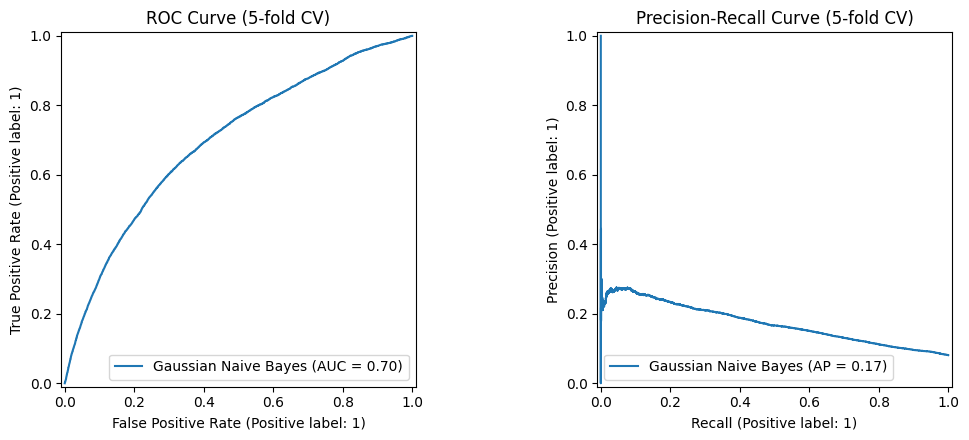

In [4]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"

nb_cv_proba = cross_val_predict(nb_pipeline, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_train, nb_cv_proba, ax=axes[0], name="Gaussian Naive Bayes")
axes[0].set_title("ROC Curve (5-fold CV)")
PrecisionRecallDisplay.from_predictions(y_train, nb_cv_proba, ax=axes[1], name="Gaussian Naive Bayes")
axes[1].set_title("Precision-Recall Curve (5-fold CV)")
plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "05_gaussian_nb_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()


In [5]:
from src.evaluation.metrics import log_result_to_csv

results_dir = "experiments/results" if os.path.exists("experiments/results") else "../experiments/results"
experiments_path = os.path.join(results_dir, "experiments.csv")

log_result_to_csv(nb_results, experiments_path)
print(f"Logged to {experiments_path}")
pd.read_csv(experiments_path)


Logged to ../experiments/results\experiments.csv


,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,XGBoost Baseline,5,0.5,0.763093,0.004383,0.261403,0.009897,0.022009,0.621743,0.042488,39.12,87542,106,7554,170
1,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.632070,0.259549,48.20,86910,738,6462,1262
2,decision_tree,5,0.5,0.708183,0.003783,0.180718,0.004465,0.606682,0.151856,0.242232,15.97,61284,26364,3038,4686
3,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.632070,0.259549,38.00,86910,738,6462,1262
4,decision_tree,5,0.5,0.708183,0.003783,0.180718,0.004465,0.606682,0.151856,0.242232,17.56,61284,26364,3038,4686
5,gaussian_naive_bayes,5,0.5,0.696815,0.003703,0.176248,0.008833,0.479027,0.169532,0.250394,16.14,69518,18130,4024,3700


**Finding:** Gaussian Naive Bayes 5-fold CV - ROC-AUC 0.697, PR-AUC 0.176, weaker than Random Forest (0.774/0.358) as expected from the broken independence assumption. Recall is higher than Random Forest at the default threshold (0.479 vs. 0.163), at the cost of much lower precision (0.170 vs. 0.632).

**Decision:** ported to `src/models/gaussian_naive_bayes.py` as `build_gaussian_naive_bayes_pipeline()`.
